In [13]:
# 自作モジュールへの変更を自動的にリロードするためのおまじない
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import lib.S2Z as stoz
import lib.Z_model as zmodel
import lib.Useful as usf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


estimated by real value : [4.81602734e-06 5.36548710e-11 3.56871159e+00]
resonance freq : 9900818.11808044
estimated by imag value : [4.92317544e-06 5.24701050e-11 3.76048993e+00]
resonance freq : 9902423.784036914


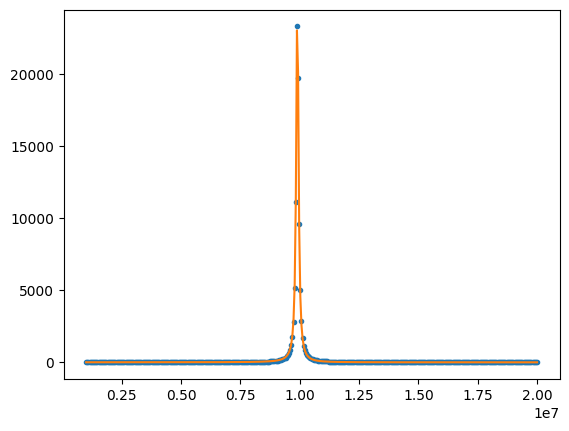

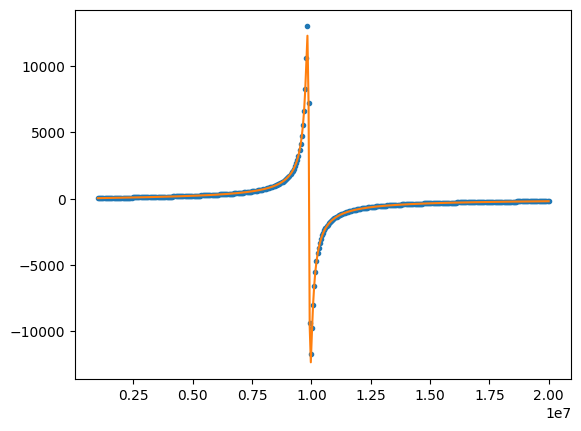

In [14]:
data = np.loadtxt("../data/LC_par_1-20MHz_2026_03_19.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, Z.real, ".")

popt, pcov = curve_fit(zmodel.L_stray_real, freq, Z.real, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_real(freq, *popt))

print("estimated by real value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

plt.figure()
plt.plot(freq, Z.imag, ".")

popt, pcov = curve_fit(zmodel.L_stray_imag, freq, Z.imag, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_imag(freq, *popt))

print("estimated by imag value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

estimated by real value : [9.54082152e-08 8.23296128e-11 7.84491668e+00]
resonance freq : 56787037.04299403
estimated by imag value : [ 6.59920274e-07 -2.17163778e-11  1.00241788e+02]
resonance freq : nan


/var/folders/ym/78fvb0xd4cs9ngj5d0z63cfr0000gn/T/ipykernel_84983/1221632889.py:20: RuntimeWarning: invalid value encountered in sqrt
  print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))


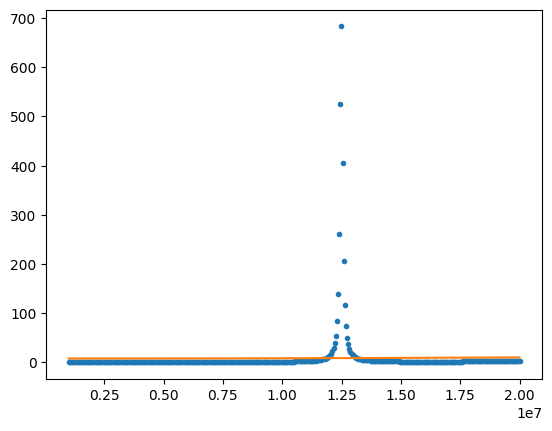

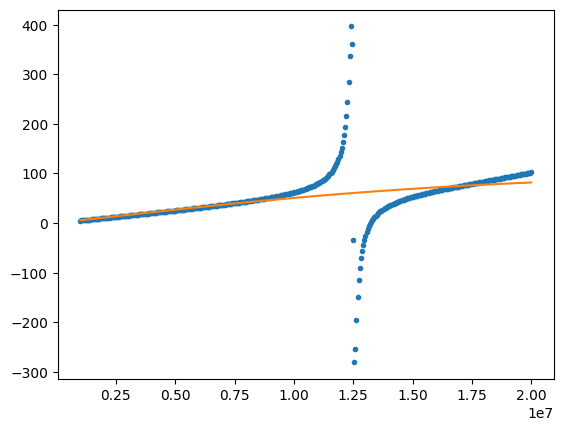

In [15]:
data = np.loadtxt("../data/LC_serial_1-20MHz_2026_03_23.s1p", delimiter=" ")
freq, Z = stoz.direct(data)


plt.plot(freq, Z.real, ".")

popt, pcov = curve_fit(zmodel.L_stray_real, freq, Z.real, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_real(freq, *popt))

print("estimated by real value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

plt.figure()
plt.plot(freq, Z.imag, ".")

popt, pcov = curve_fit(zmodel.L_stray_imag, freq, Z.imag, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_imag(freq, *popt))

print("estimated by imag value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

estimated by real value : [1.29502085e-07 8.22629982e-11 4.60445166e+00]
resonance freq : 48761772.52776681
estimated by imag value : [ 8.01693827e-07  2.69552605e-12 -7.53372429e+00]
resonance freq : 108266499.3856468


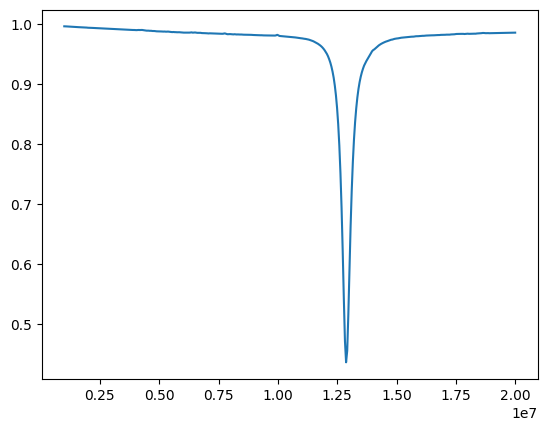

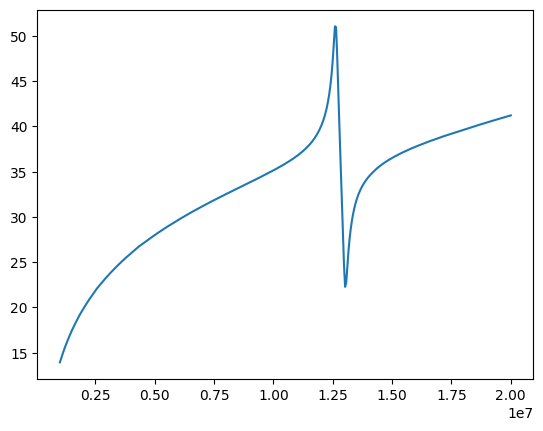

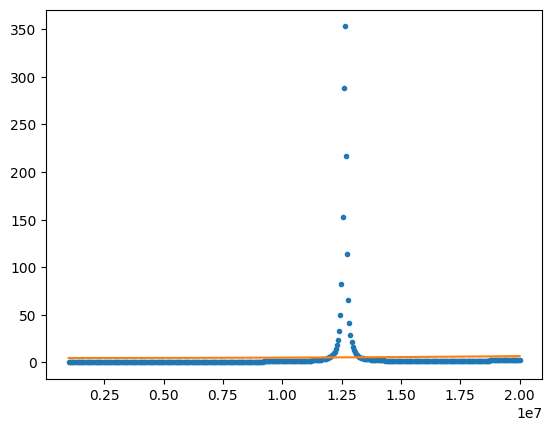

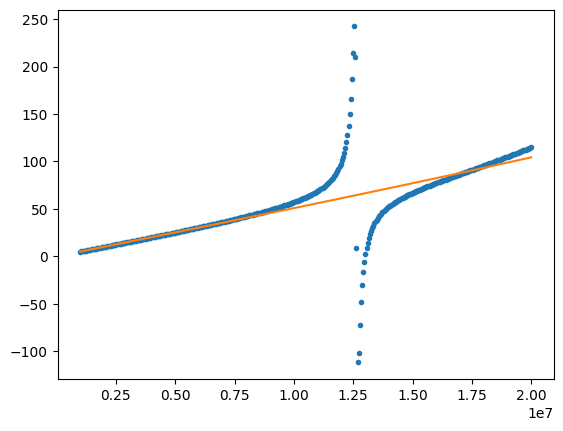

In [16]:
data = np.loadtxt("../data/LC_serial_1-20MHz_2026_03_23_2.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, usf.db(Z))
plt.figure()
plt.plot(freq, Z.real, ".")

popt, pcov = curve_fit(zmodel.L_stray_real, freq, Z.real, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_real(freq, *popt))

print("estimated by real value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

plt.figure()
plt.plot(freq, Z.imag, ".")

popt, pcov = curve_fit(zmodel.L_stray_imag, freq, Z.imag, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_imag(freq, *popt))

print("estimated by imag value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

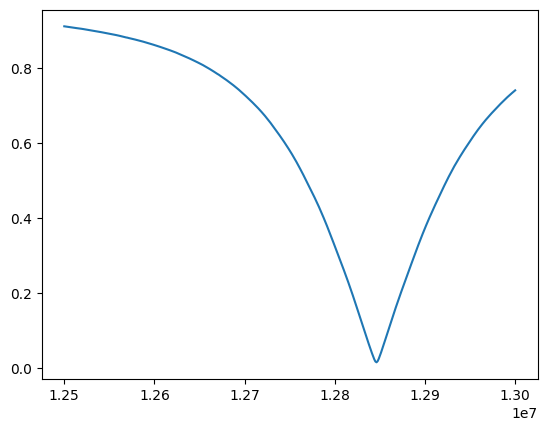

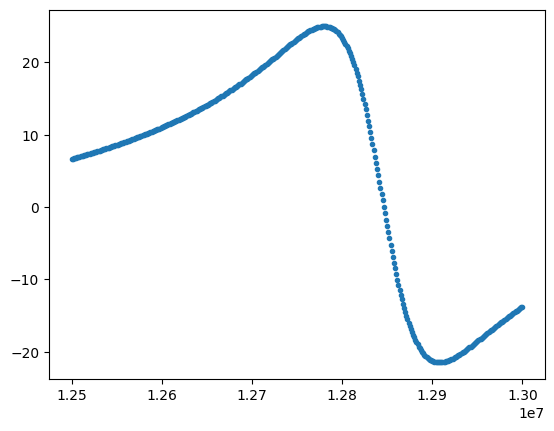

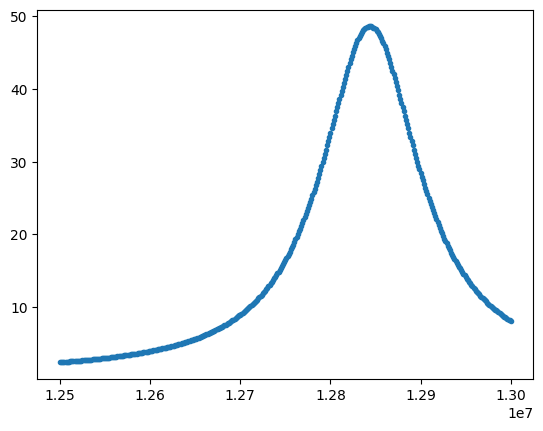

<Figure size 640x480 with 0 Axes>

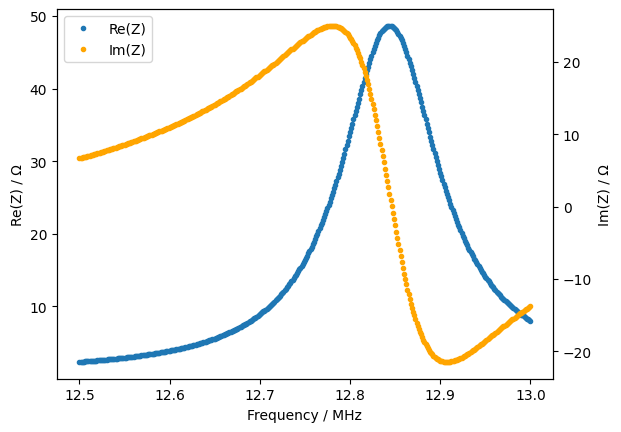

In [38]:
data = np.loadtxt("../data/LC_serial_with_trimmer_just_2026_03_23.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()


fig, ax1 = plt.subplots()

# 左軸（実部）
ax1.plot(freq * 1e-6, Z.real,".", label="Re(Z)")
ax1.set_xlabel("Frequency / MHz")
ax1.set_ylabel("Re(Z) / Ω")
ax1.tick_params(axis='y')

# 右軸（リアクタンス）
ax2 = ax1.twinx()
ax2.plot(freq * 1e-6, Z.imag, ".", label="Im(Z)", color = "orange")
ax2.set_ylabel("Im(Z) / Ω")
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

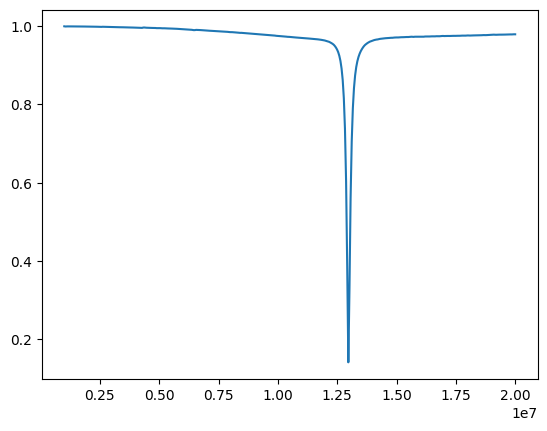

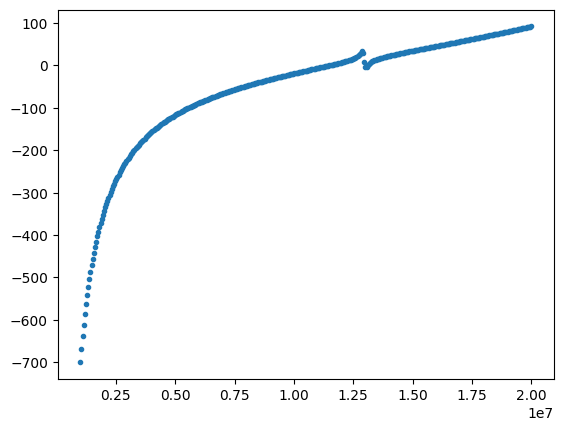

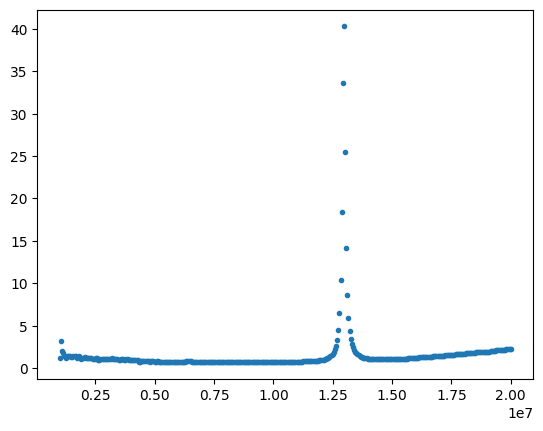

<Figure size 640x480 with 0 Axes>

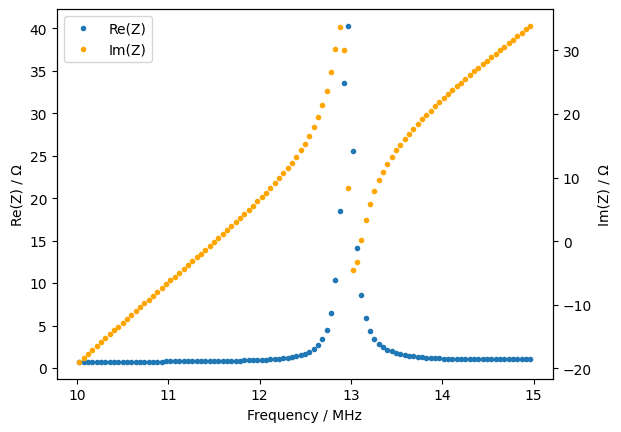

In [39]:
data = np.loadtxt("../data/LC_serial_with_trimmer_faraway_2026_03_23.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()

mask = (freq >= 10e6) & (freq <= 15e6)
freq_mask = freq[mask]
Z_mask = Z[mask]

fig, ax1 = plt.subplots()

# 左軸（実部）
ax1.plot(freq_mask * 1e-6, Z_mask.real,".", label="Re(Z)")
ax1.set_xlabel("Frequency / MHz")
ax1.set_ylabel("Re(Z) / Ω")
ax1.tick_params(axis='y')

# 右軸（リアクタンス）
ax2 = ax1.twinx()
ax2.plot(freq_mask * 1e-6, Z_mask.imag, ".", label="Im(Z)", color = "orange")
ax2.set_ylabel("Im(Z) / Ω")
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()


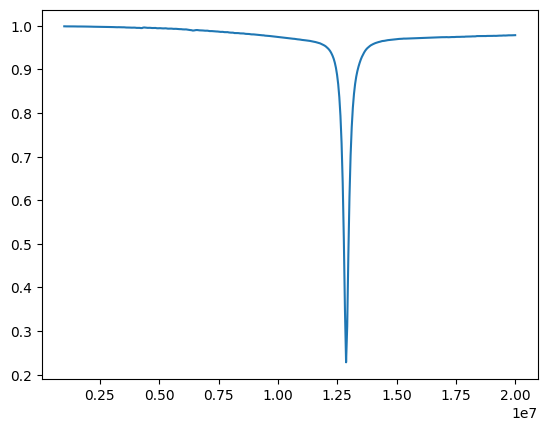

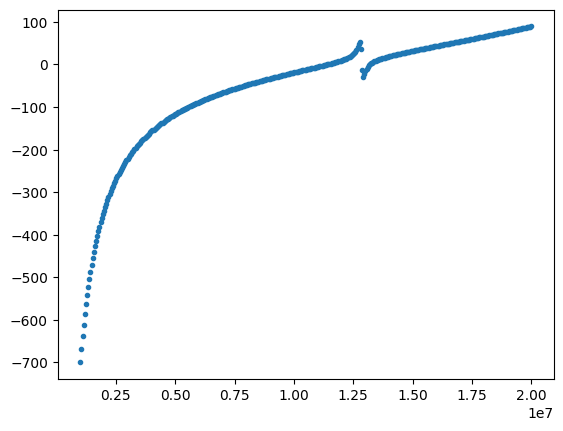

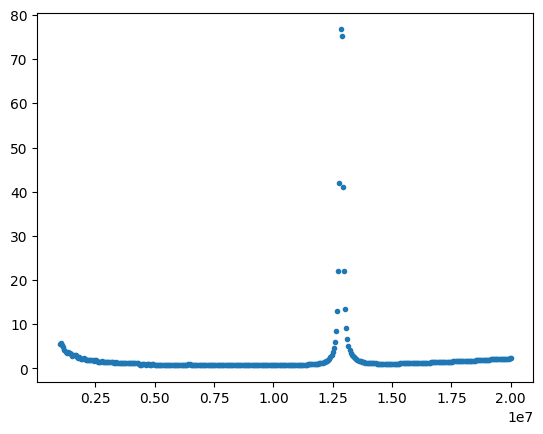

<Figure size 640x480 with 0 Axes>

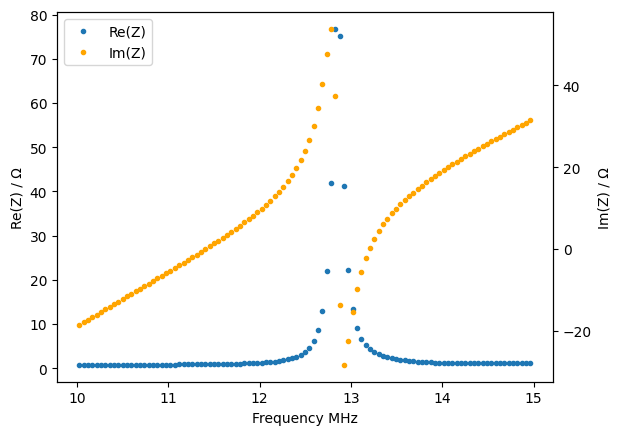

In [ ]:
data = np.loadtxt("../data/LC_serial_with_trimmer_moderate_2026_03_23.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()

mask = (freq >= 10e6) & (freq <= 15e6)
freq_mask = freq[mask]
Z_mask = Z[mask]

fig, ax1 = plt.subplots()

# 左軸（実部）
ax1.plot(freq_mask*1e-6, Z_mask.real,".", label="Re(Z)")
ax1.set_xlabel("Frequency / MHz")
ax1.set_ylabel("Re(Z) / Ω")
ax1.tick_params(axis='y')

# 右軸（リアクタンス）
ax2 = ax1.twinx()
ax2.plot(freq_mask*1e-6, Z_mask.imag, ".", label="Im(Z)", color = "orange")
ax2.set_ylabel("Im(Z) / Ω")
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

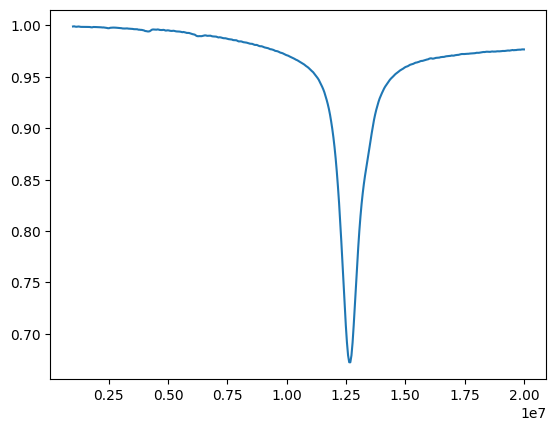

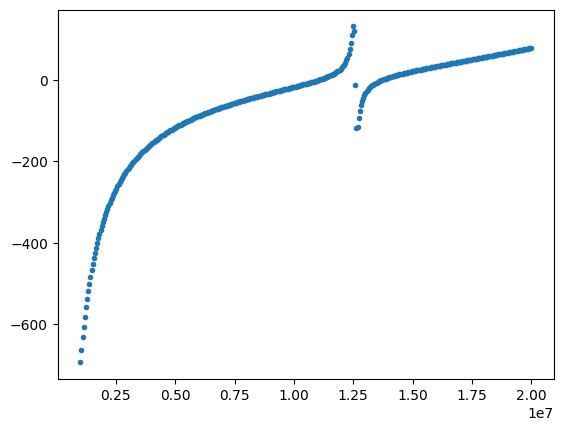

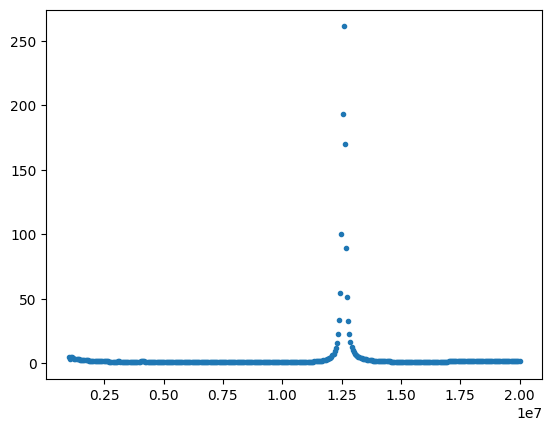

<Figure size 640x480 with 0 Axes>

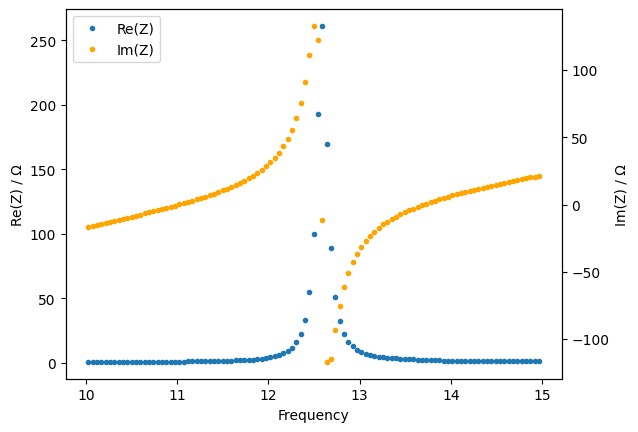

In [41]:
data = np.loadtxt("../data/LC_serial_with_trimmer_tooconnected_2026_03_23.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()

mask = (freq >= 10e6) & (freq <= 15e6)
freq_mask = freq[mask]
Z_mask = Z[mask]

fig, ax1 = plt.subplots()

# 左軸（実部）
ax1.plot(freq_mask*1e-6, Z_mask.real,".", label="Re(Z)")
ax1.set_xlabel("Frequency")
ax1.set_ylabel("Re(Z) / Ω")
ax1.tick_params(axis='y')

# 右軸（リアクタンス）
ax2 = ax1.twinx()
ax2.plot(freq_mask*1e-6, Z_mask.imag, ".", label="Im(Z)", color = "orange")
ax2.set_ylabel("Im(Z) / Ω")
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

<Figure size 640x480 with 0 Axes>

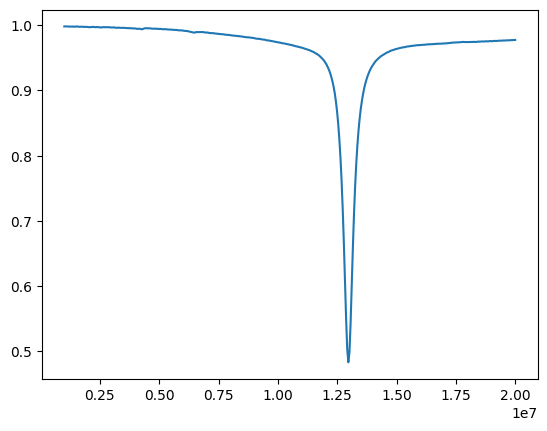

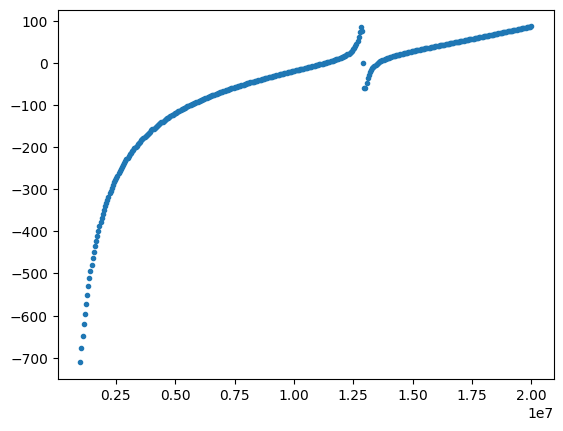

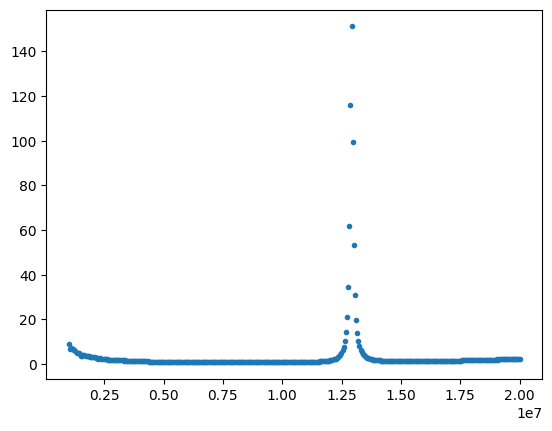

<Figure size 640x480 with 0 Axes>

In [26]:
data = np.loadtxt("../data/LC_serial_without_hand_1-20M_2026_03_30.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()

<Figure size 640x480 with 0 Axes>

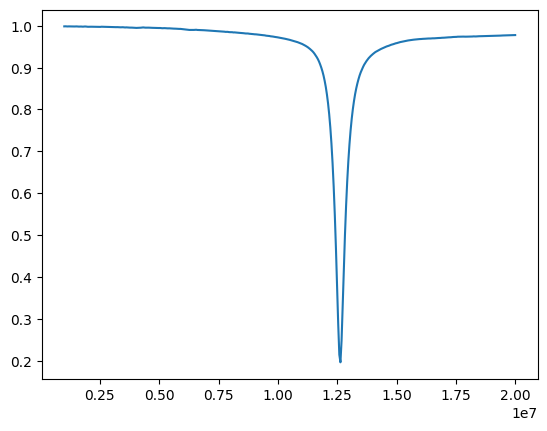

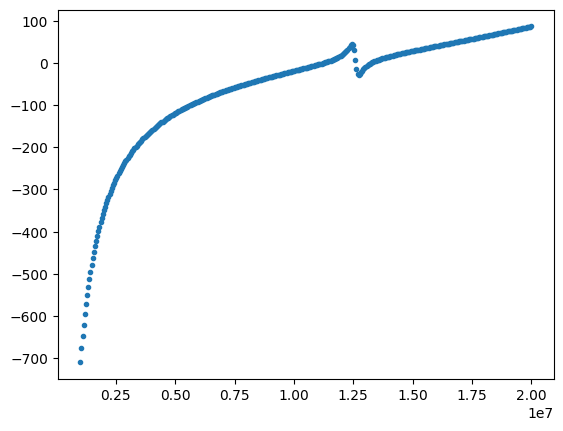

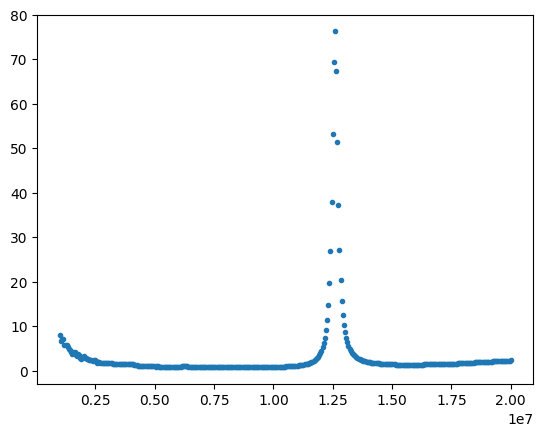

<Figure size 640x480 with 0 Axes>

In [22]:
data = np.loadtxt("../data/LC_serial_witrh_hand_1-20M_2026_03_30.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, np.abs(data[:, 1] + 1j * data[:, 2]))
plt.figure()

plt.plot(freq, Z.imag, ".")
plt.figure()

plt.plot(freq, Z.real, ".")
plt.figure()